In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
try:
    with open('corp0.txt', 'r', encoding='utf-8') as f:
        lines = f.readlines()
    print(f"Файл загружен")
except FileNotFoundError:
    print("Файл не найден")

Файл загружен


In [3]:
data = []
for line in lines:
    line = line.strip()
    if line and line.startswith('#'):
        parts = line[1:].split(' ', 1) 
        if len(parts) == 2:
            category = parts[0].strip()
            text = parts[1].strip()
            data.append({'category': category, 'text': text})

df = pd.DataFrame(data)
print(f"Создан датафрейм: {df.shape}")
print(f"Уникальных категорий: {df['category'].nunique()}")
print(f"Категории: {sorted(df['category'].unique())}")

Создан датафрейм: (3400, 2)
Уникальных категорий: 13
Категории: ['автомобили', 'здоровье', 'культура', 'наука', 'недвижимость', 'политика', 'происшествия', 'реклама', 'семья', 'спорт', 'страна', 'техника', 'экономика']


In [5]:
category_counts = df['category'].value_counts().sort_index()

print("\nКоличество документов по категориям:")
for cat, count in category_counts.items():
    print(f" {cat}: {count}")


Количество документов по категориям:
 автомобили: 249
 здоровье: 157
 культура: 358
 наука: 227
 недвижимость: 98
 политика: 600
 происшествия: 436
 реклама: 94
 семья: 101
 спорт: 373
 страна: 146
 техника: 289
 экономика: 272


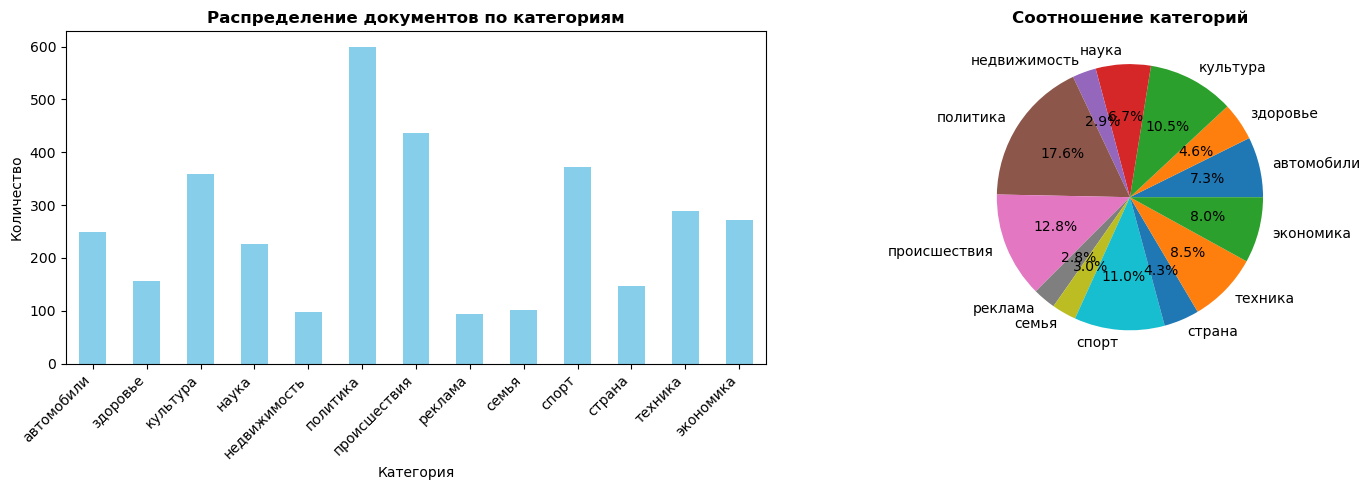

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
category_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение документов по категориям', fontweight='bold')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
category_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Соотношение категорий', fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^а-яё\s]', '', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

In [9]:
russian_stop_words = [
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 
    'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 
    'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 
    'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 
    'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 
    'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 
    'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 
    'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 
    'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 
    'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 
    'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 
    'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 
    'про', 'всего', 'них', 'какая', 'много', 'разве', 'сказал', 'три', 'эту', 'моя', 
    'впрочем', 'хорошо', 'свою', 'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том', 
    'нельзя', 'такой', 'им', 'более', 'всегда', 'конечно', 'всю', 'между'
]


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


vectorizer = TfidfVectorizer(
    max_features=15000,        
    min_df=3,                   
    max_df=0.7,                  
    ngram_range=(1, 3),         
    stop_words=russian_stop_words, 
    sublinear_tf=True,          
    use_idf=True                 
)

X = vectorizer.fit_transform(df['clean_text'])

In [11]:
print(f"Матрица признаков X: {X.shape}")

Матрица признаков X: (3400, 15000)


In [12]:
le = LabelEncoder()
y = le.fit_transform(df['category'])
print(f" Целевая переменная y: {y.shape}")
print(f"   Классы: {dict(zip(le.classes_, le.transform(le.classes_)))}")

 Целевая переменная y: (3400,)
   Классы: {'автомобили': np.int64(0), 'здоровье': np.int64(1), 'культура': np.int64(2), 'наука': np.int64(3), 'недвижимость': np.int64(4), 'политика': np.int64(5), 'происшествия': np.int64(6), 'реклама': np.int64(7), 'семья': np.int64(8), 'спорт': np.int64(9), 'страна': np.int64(10), 'техника': np.int64(11), 'экономика': np.int64(12)}


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
print("\nРаспределение классов в обучающей выборке:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"   Класс {cls} ({le.classes_[cls]}): {count}")


Распределение классов в обучающей выборке:
   Класс 0 (автомобили): 199
   Класс 1 (здоровье): 126
   Класс 2 (культура): 286
   Класс 3 (наука): 182
   Класс 4 (недвижимость): 78
   Класс 5 (политика): 480
   Класс 6 (происшествия): 349
   Класс 7 (реклама): 75
   Класс 8 (семья): 81
   Класс 9 (спорт): 298
   Класс 10 (страна): 117
   Класс 11 (техника): 231
   Класс 12 (экономика): 218


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [18]:
results = {}
model1 = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42,
    class_weight='balanced',
    multi_class='ovr',
    n_jobs=-1
)

model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)
f1_1 = f1_score(y_test, y_pred1, average='weighted')

results['Logistic Regression'] = {'Accuracy': acc1, 'F1-Score': f1_1}

print(f"\nРезультаты:")
print(f"   Accuracy: {acc1:.4f}")
print(f"   F1-Score: {f1_1:.4f}")

pred_dist = pd.Series(y_pred1).value_counts().sort_index()
print(f"\nПредсказано классов: {len(pred_dist)} из {len(np.unique(y_test))}")


Результаты:
   Accuracy: 0.8721
   F1-Score: 0.8713

Предсказано классов: 13 из 13


In [19]:
model2 = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=42,
    class_weight='balanced',
    dual=False
)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, y_pred2)
f1_2 = f1_score(y_test, y_pred2, average='weighted')

results['Linear SVC'] = {'Accuracy': acc2, 'F1-Score': f1_2}
print(f"   Accuracy: {acc2:.4f}")
print(f"   F1-Score: {f1_2:.4f}")

   Accuracy: 0.8824
   F1-Score: 0.8810


In [20]:
model3 = MultinomialNB(alpha=0.1)

model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

acc3 = accuracy_score(y_test, y_pred3)
f1_3 = f1_score(y_test, y_pred3, average='weighted')

results['Multinomial NB'] = {'Accuracy': acc3, 'F1-Score': f1_3}

print(f"   Accuracy: {acc3:.4f}")
print(f"   F1-Score: {f1_3:.4f}")

   Accuracy: 0.8529
   F1-Score: 0.8479


In [21]:
model4 = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)


model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)

acc4 = accuracy_score(y_test, y_pred4)
f1_4 = f1_score(y_test, y_pred4, average='weighted')

results['Random Forest'] = {'Accuracy': acc4, 'F1-Score': f1_4}

print(f"\n Результаты:")
print(f"   Accuracy: {acc4:.4f}")
print(f"   F1-Score: {f1_4:.4f}")


 Результаты:
   Accuracy: 0.7485
   F1-Score: 0.7567


In [22]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = np.array([class_weights[i] for i in y_train])

model5 = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

model5.fit(X_train, y_train, sample_weight=sample_weights)
y_pred5 = model5.predict(X_test)

acc5 = accuracy_score(y_test, y_pred5)
f1_5 = f1_score(y_test, y_pred5, average='weighted')

results['XGBoost'] = {'Accuracy': acc5, 'F1-Score': f1_5}

print(f"\n Результаты:")
print(f"   Accuracy: {acc5:.4f}")
print(f"   F1-Score: {f1_5:.4f}")


 Результаты:
   Accuracy: 0.7779
   F1-Score: 0.7804


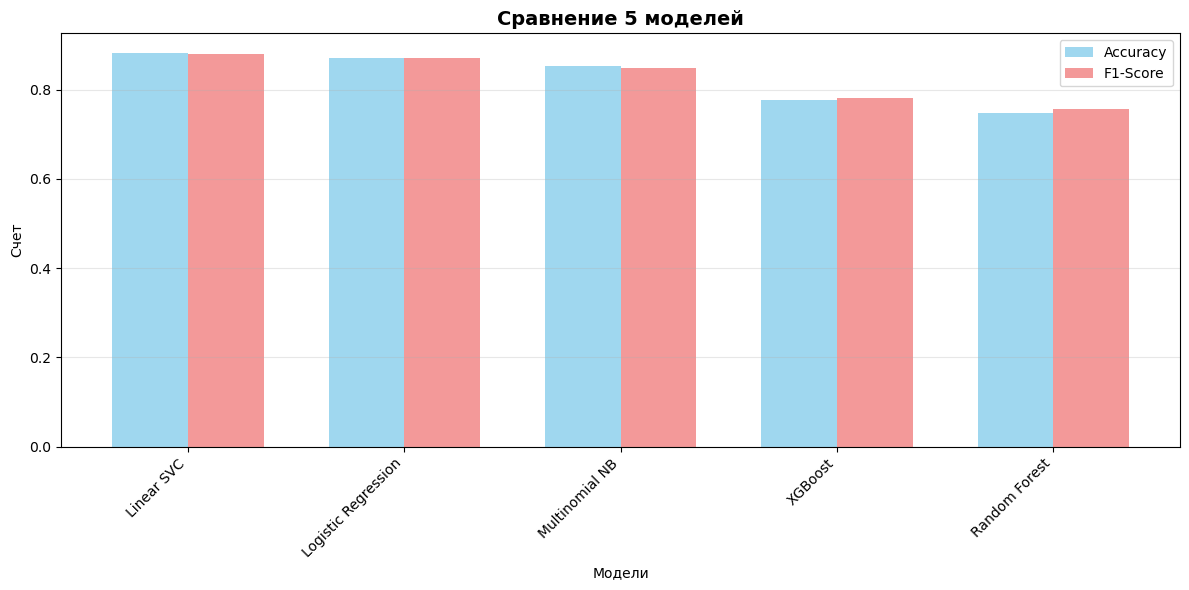

In [23]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)
plt.figure(figsize=(12, 6))

x_pos = np.arange(len(results_df))
width = 0.35

plt.bar(x_pos - width/2, results_df['Accuracy'], width, label='Accuracy', alpha=0.8, color='skyblue')
plt.bar(x_pos + width/2, results_df['F1-Score'], width, label='F1-Score', alpha=0.8, color='lightcoral')

plt.xlabel('Модели')
plt.ylabel('Счет')
plt.title('Сравнение 5 моделей', fontweight='bold', fontsize=14)
plt.xticks(x_pos, results_df.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

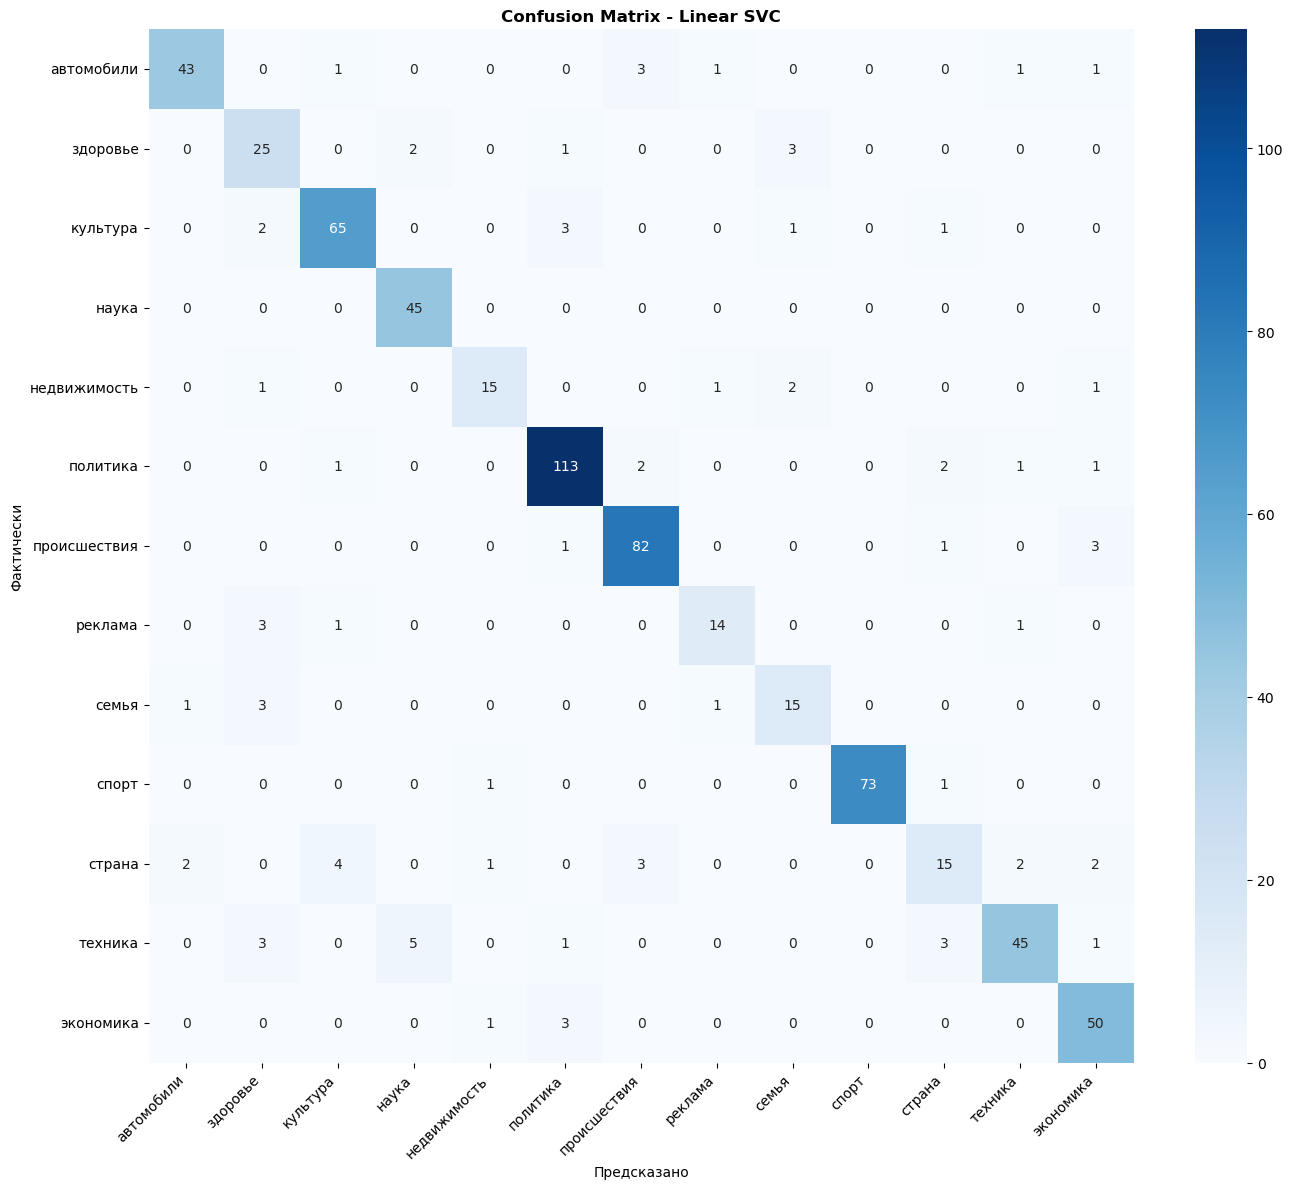

In [27]:
#Детальнее хочу посмотреть на лучшую модель
best_model_name = results_df.index[0]
best_model_idx = list(results.keys()).index(best_model_name) + 1
best_model = locals()[f'model{best_model_idx}']
y_pred_best = locals()[f'y_pred{best_model_idx}']

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
print(classification_report(y_test, y_pred_best, 
                           target_names=le.classes_,
                           zero_division=0))

              precision    recall  f1-score   support

  автомобили       0.93      0.86      0.90        50
    здоровье       0.68      0.81      0.74        31
    культура       0.90      0.90      0.90        72
       наука       0.87      1.00      0.93        45
недвижимость       0.83      0.75      0.79        20
    политика       0.93      0.94      0.93       120
происшествия       0.91      0.94      0.93        87
     реклама       0.82      0.74      0.78        19
       семья       0.71      0.75      0.73        20
       спорт       1.00      0.97      0.99        75
      страна       0.65      0.52      0.58        29
     техника       0.90      0.78      0.83        58
   экономика       0.85      0.93      0.88        54

    accuracy                           0.88       680
   macro avg       0.85      0.84      0.84       680
weighted avg       0.88      0.88      0.88       680



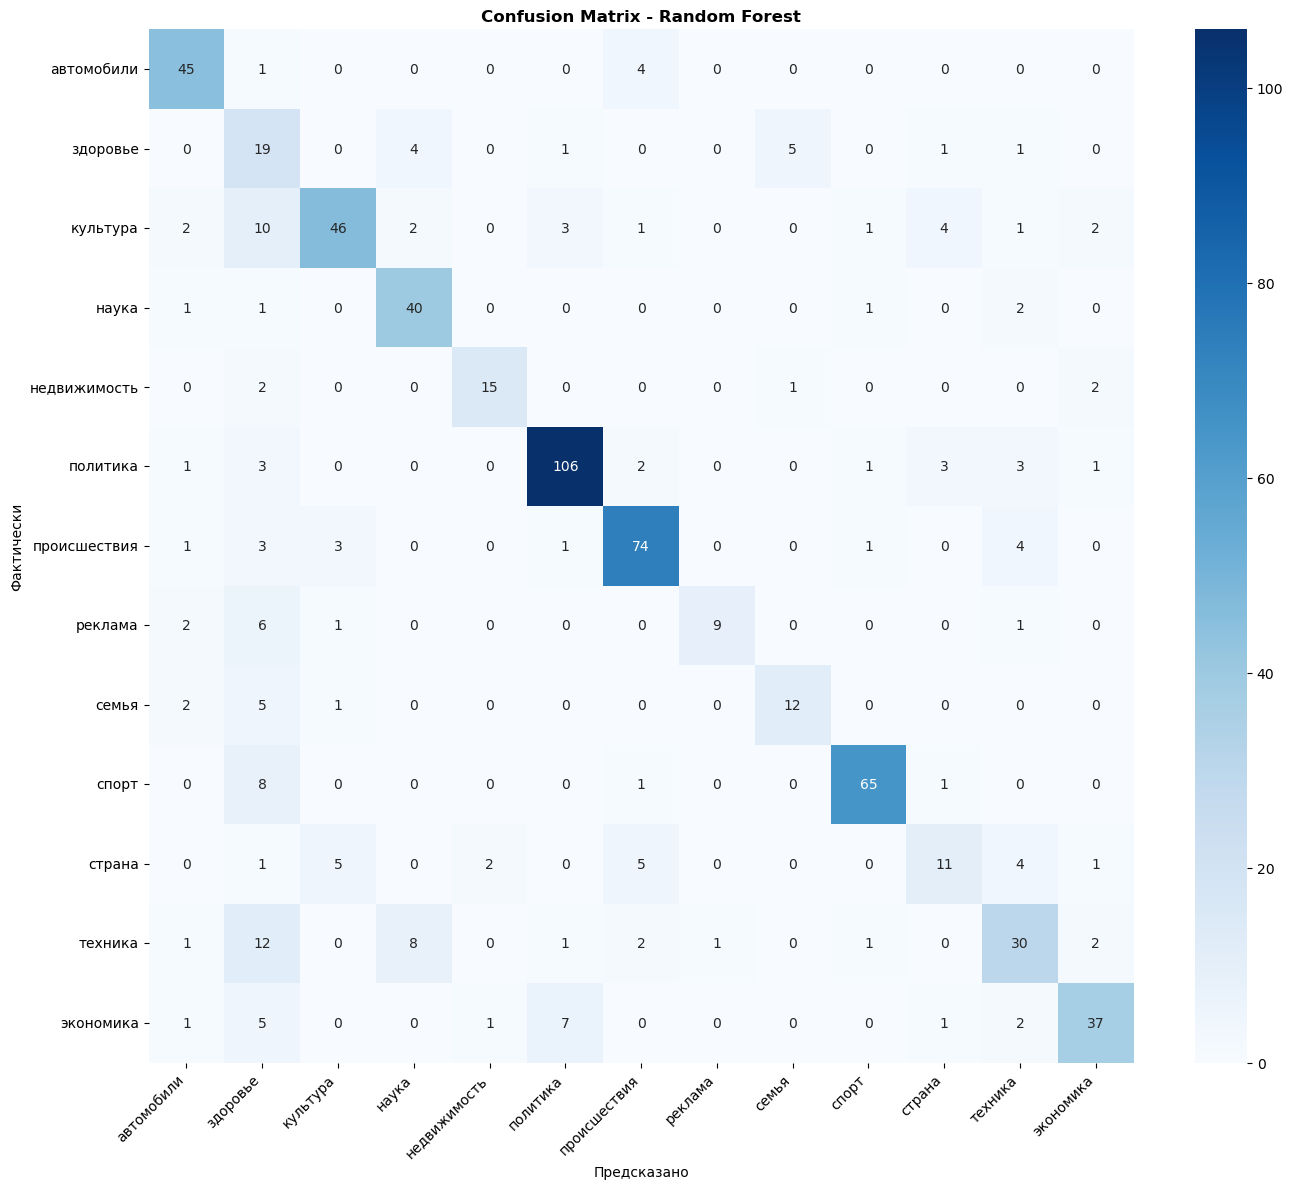

In [30]:
#Теперь на самую плохую модель
model_name = results_df.index[4]
model_idx = list(results.keys()).index(model_name) + 1
model = locals()[f'model{model_idx}']
y_pred = locals()[f'y_pred{model_idx}']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {model_name}', fontweight='bold')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
print(classification_report(y_test, y_pred, 
                           target_names=le.classes_,
                           zero_division=0))

              precision    recall  f1-score   support

  автомобили       0.80      0.90      0.85        50
    здоровье       0.25      0.61      0.36        31
    культура       0.82      0.64      0.72        72
       наука       0.74      0.89      0.81        45
недвижимость       0.83      0.75      0.79        20
    политика       0.89      0.88      0.89       120
происшествия       0.83      0.85      0.84        87
     реклама       0.90      0.47      0.62        19
       семья       0.67      0.60      0.63        20
       спорт       0.93      0.87      0.90        75
      страна       0.52      0.38      0.44        29
     техника       0.62      0.52      0.57        58
   экономика       0.82      0.69      0.75        54

    accuracy                           0.75       680
   macro avg       0.74      0.70      0.70       680
weighted avg       0.78      0.75      0.76       680

